# Beyond K-Means

K-Means is a very useful starting point, but it is not the only clustering method. Two important alternatives are:

- Hierarchical Clustering
- DBSCAN

## Hierarchical Clustering

Hierarchical clustering builds a **hierarchy of clusters** instead of assigning all points at once.

### Key Idea
Instead of fixing the number of clusters beforehand, hierarchical clustering creates a **tree-like structure** of clusters. This structure is called a **dendrogram**

A dendrogram shows:
- How clusters are merged or split  
- The distance at which this happens  

By “cutting” the dendrogram at a certain height, we choose the number of clusters.

<p align="center">
  <img src="https://miro.medium.com/v2/0*0gop9RK2hvVlcBBR.png" width="500"/>
</p>

<p align="center">
<b>Figure:</b> Dendrogram illustrating hierarchical clustering. The vertical axis shows the distance at which clusters are merged, and cutting the tree at different heights results in different numbers of clusters.  
<sub>Source: Medium</sub>
</p>

There are **two common approaches**:

- **(1) Agglomerative:** (Start small → merge upward) Start with each point as its own cluster, then repeatedly merge the closest clusters.

- **(2) Divisive:** (Start big → split downward) Start with one large cluster, then repeatedly split it

> Agglomerative merges clusters step-by-step, while divisive splits clusters step-by-step, forming a hierarchy of clusters.



#### (1) Agglomerative (Bottom-Up): How it works:
Start with individual points → merge clusters  
> Compute all distances → pick the smallest → merge → repeat
#### Algorithm Steps:

1. **Initialize**:  
   Treat each data point as its own cluster  


2. **Compute Distance Matrix**:  
   Calculate pairwise distances between all clusters  

   > Distance between clusters depends on the **linkage method**:

   > - **Single Linkage:** minimum distance between any two points  
   > - **Complete Linkage:** maximum distance between any two points  
   > - **Average Linkage:** average distance between all pairs  
   > - **Ward’s Method:** minimizes variance within clusters  

   > The **linkage method controls how clusters are merged**, and can significantly affect the final clustering structure.

<p align="center">
  <img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2021/06/40351linkages-676cf4c719722.webp" width="450"/>
</p>

<p align="center">
<b>Figure:</b> Comparison of linkage methods in hierarchical clustering: single, complete, average, and Ward’s method.  
Single linkage may create long chains, while complete linkage produces tighter and more compact clusters.  
<sub>Source: Analytics Vidhya</sub>
</p>

This step gives us a **table of distances between every pair of clusters**

**Example: Distance Matrix**

|   | A | B | C |
|---|---|---|---|
| A | — | 2 | 5 |
| B | 2 | — | 3 |
| C | 5 | 3 | — |


3. **Find Closest Clusters**:  
   From the distance matrix, identify the **two clusters with the smallest distance**

   - Example: smallest distance = **2 (A–B)**  
   - So clusters **A and B** will be merged next  



4. **Merge Clusters**:  
   Combine the selected clusters into a single cluster  


5. **Update Distances**:  
   Recompute distances between the new cluster and all others  
   (using the same linkage method)

6. **Repeat Steps 3–5**  
   Continue until:
   - Only one cluster remains OR  
   - Desired number of clusters is reached  


<!--
1. Start with each data point as its own cluster  
2. Compute distances between all clusters  
3. Merge the two closest clusters  
4. Update distances between new clusters  
5. Repeat until all points form one cluster   -->

#### (2) Divisive (Top-Down): How it works:

Start with one cluster → split into smaller clusters

#### Algorithm Steps:

1. **Initialize**:  
   Put all data points into one cluster  

2. **Select** Cluster to **Split**:  
   Choose the cluster that is most heterogeneous  
   (e.g., highest variance or largest size)  

3. **Split** Cluster:  
   Divide it into two smaller or sub clusters (often using a method like K-Means).cThe goal is to maximize separation between the two new clusters

4. **Evaluate** Split:  
   Check if further splitting improves cluster quality (e.g., better separation or reduced variance).  

5. **Repeat** Steps 2–4  
   Continue until:
   - Each point is its own cluster OR  
   - Desired number of clusters is reached  


> Divisive clustering is less commonly used because splitting is computationally more complex than merging.

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20250623130357052817/divisive_clustering.jpg" width="450"/>
</p>

<p align="center">
<b>Figure:</b> Divisive clustering process (top-down). The algorithm starts with one large cluster and recursively splits it into smaller clusters until the desired structure is obtained.  
<sub>Source: GeeksforGeeks</sub>
</p>


<!-- 1. Start with all data points in one cluster  
2. Split the cluster into smaller clusters  
3. Continue splitting recursively  
4. Stop when each point is its own cluster or desired number is reached   -->


<!-- ## Linkage Methods (Important for Agglomerative)

Distance between clusters can be defined in different ways:

- **Single Linkage:** minimum distance between points  
- **Complete Linkage:** maximum distance between points  
- **Average Linkage:** average distance  
- **Ward’s Method:** minimizes variance within clusters  

Choice of linkage affects cluster shape and structure -->


## Why Use Hierarchical Clustering?

- No need to specify number of clusters initially  
- Provides insight into data structure  
- Useful for small to medium datasets  

## Limitation

- Computationally expensive for large datasets  
- Decisions (merge/split) cannot be undone  



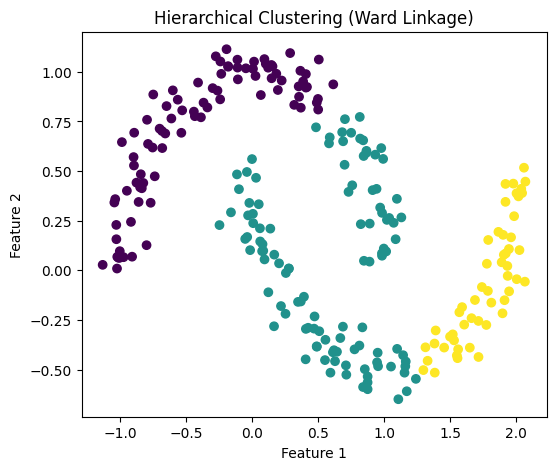

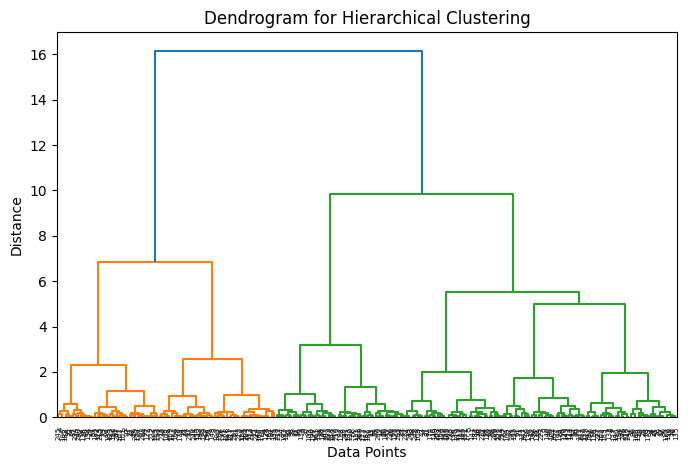

In [7]:
# Python Example
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Sample dataset
X, _ = make_moons(n_samples=250, noise=0.08, random_state=42)

# Apply Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X)

# -----------------------------
# Plot 1: Hierarchical Clusters
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=hc_labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering (Ward Linkage)")
plt.show()

# -----------------------------
# Plot 2: Dendrogram
# -----------------------------
Z = linkage(X, method='ward')

plt.figure(figsize=(8,5))
dendrogram(Z)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()



# DBSCAN

DBSCAN stands for: **Density-Based Spatial Clustering of Applications with Noise**. Unlike K-Means, DBSCAN does not try to create a fixed number of clusters. Instead, it groups together points that are packed closely together and labels isolated points as noise.

## Main Idea
- Dense regions form clusters
- Sparse regions may be treated as outliers

This makes DBSCAN especially useful when:
- Clusters have irregular shapes  
- The dataset contains noise or outliers  
- Number of clusters is **unknown**

### Key Parameters:

DBSCAN uses two parameters: **ε** (neighborhood radius) and **minPts** (minimum points) to define dense regions and form clusters.

- **ε (epsilon):** radius defining neighborhood  
- **minPts:** minimum number of points required to form a dense region  


## Types of Points

- **Core Point:** has at least `minPts` neighbors within ε  
- **Border Point:** close to a core point but not dense enough itself  
- **Noise Point:** not close to any cluster  


## How DBSCAN Works

1. Pick an unvisited point  
2. Find all points within distance **ε** (epsilon)
   - This forms the point’s **neighborhood**

3. Check if the neighborhood has at least **minPts** points  

   - If YES → it is a **core point**, start a new cluster  
   - If NO → mark it as **noise** (may later become a border point)

4. Expand the cluster:
   - Add all points within ε of the core point  
   - For each new point:
     - If it also has ≥ minPts neighbors → expand further  
   This creates a **chain of density-connected points**

5. Repeat until all reachable points are added  
6. Move to next unvisited point and repeat  

> DBSCAN finds clusters based on density, grouping nearby points together while identifying sparse points as noise.

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20250912174514326431/4.webp" width="450"/>
</p>

<p align="center">
<b>Figure:</b> DBSCAN clustering showing core points (dense regions), border points (edges of clusters), and noise points (outliers).  
<sub>Source: GeeksforGeeks</sub>
</p>

In this figure:
- **Core points** form the dense center of clusters  
- **Border points** lie on the edges of clusters  
- **Noise points** are isolated and do not belong to any cluster  

DBSCAN builds clusters by expanding from core points and including all **density-connected** points (points reachable through neighboring core points).


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# -----------------------
# Generate dataset
# -----------------------
X, _ = make_moons(n_samples=200, noise=0.08, random_state=42)

# Parameters
eps = 0.25
minPts = 5

# Pick a starting point
start_idx = 100
start_point = X[start_idx]

# Find neighbors within epsilon
nbrs = NearestNeighbors(radius=eps)
nbrs.fit(X)
neighbors = nbrs.radius_neighbors([start_point], return_distance=False)[0]

# Final DBSCAN result
db = DBSCAN(eps=eps, min_samples=minPts)
labels = db.fit_predict(X)

# -----------------------
# Set up figure
# -----------------------
fig, ax = plt.subplots(figsize=(6, 5))

def draw_base():
    ax.clear()
    ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
    ax.set_aspect("equal")

def update(frame):
    draw_base()

    if frame == 0:
        ax.scatter(X[:, 0], X[:, 1], alpha=0.7)
        ax.set_title("Step 1: Original Data")

    elif frame == 1:
        ax.scatter(X[:, 0], X[:, 1], alpha=0.7)
        ax.scatter(start_point[0], start_point[1], s=120, marker='x')
        ax.set_title("Step 2: Select an Unvisited Point")

    elif frame == 2:
        ax.scatter(X[:, 0], X[:, 1], alpha=0.7)
        ax.scatter(start_point[0], start_point[1], s=120, marker='x')
        circle = plt.Circle((start_point[0], start_point[1]), eps, fill=False, linewidth=2)
        ax.add_patch(circle)
        ax.set_title("Step 3: Find Points Within ε")

    elif frame == 3:
        ax.scatter(X[:, 0], X[:, 1], alpha=0.25)
        ax.scatter(X[neighbors, 0], X[neighbors, 1], alpha=0.95)
        ax.scatter(start_point[0], start_point[1], s=120, marker='x')
        circle = plt.Circle((start_point[0], start_point[1]), eps, fill=False, linewidth=2)
        ax.add_patch(circle)
        ax.set_title(f"Step 4: Neighborhood Size = {len(neighbors)}")

    elif frame == 4:
        ax.scatter(X[:, 0], X[:, 1], alpha=0.25)
        ax.scatter(X[neighbors, 0], X[neighbors, 1], alpha=0.95)
        ax.scatter(start_point[0], start_point[1], s=120, marker='x')
        circle = plt.Circle((start_point[0], start_point[1]), eps, fill=False, linewidth=2)
        ax.add_patch(circle)

        if len(neighbors) >= minPts:
            ax.set_title(f"Step 5: Core Point ({len(neighbors)} ≥ {minPts}) → Start Cluster")
        else:
            ax.set_title(f"Step 5: Not a Core Point ({len(neighbors)} < {minPts}) → Noise/Border")

    elif frame == 5:
        unique_labels = sorted(set(labels))
        for label in unique_labels:
            if label == -1:
                ax.scatter(
                    X[labels == label, 0],
                    X[labels == label, 1],
                    color='black',
                    label='Noise'
                )
            else:
                ax.scatter(
                    X[labels == label, 0],
                    X[labels == label, 1],
                    label=f'Cluster {label}'
                )
        ax.legend()
        ax.set_title("Final DBSCAN Clustering Result")

anim = FuncAnimation(fig, update, frames=6, interval=1800, repeat=True)

plt.close(fig)
HTML(anim.to_jshtml())

## Why use DBSCAN?
- Does not require specifying the number of clusters in advance
- Can detect outliers
- Works well for arbitrarily shaped clusters

##Limitation
Sensitive to parameter choices such as eps and min_samples

## Comparing the Methods
K-Means
- Best for compact, spherical clusters
- Requires choosing K

Hierarchical Clustering

- Builds a tree-like clustering structure
- Useful for exploring relationships between clusters

DBSCAN

- Density-based
- Handles noise and irregular cluster shapes better